In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import fit_model as fm 
import os
from set_data import set_data

tracks, MT_conc, mc_conc, scale, interval = set_data()

plt.style.use('my_style.mplstyle')
markers = ["o", "s", "v", "^", '*', 'd']
lines = ["-", "--", "-.", ":", (0, (5, 3, 1, 3, 1, 3))]

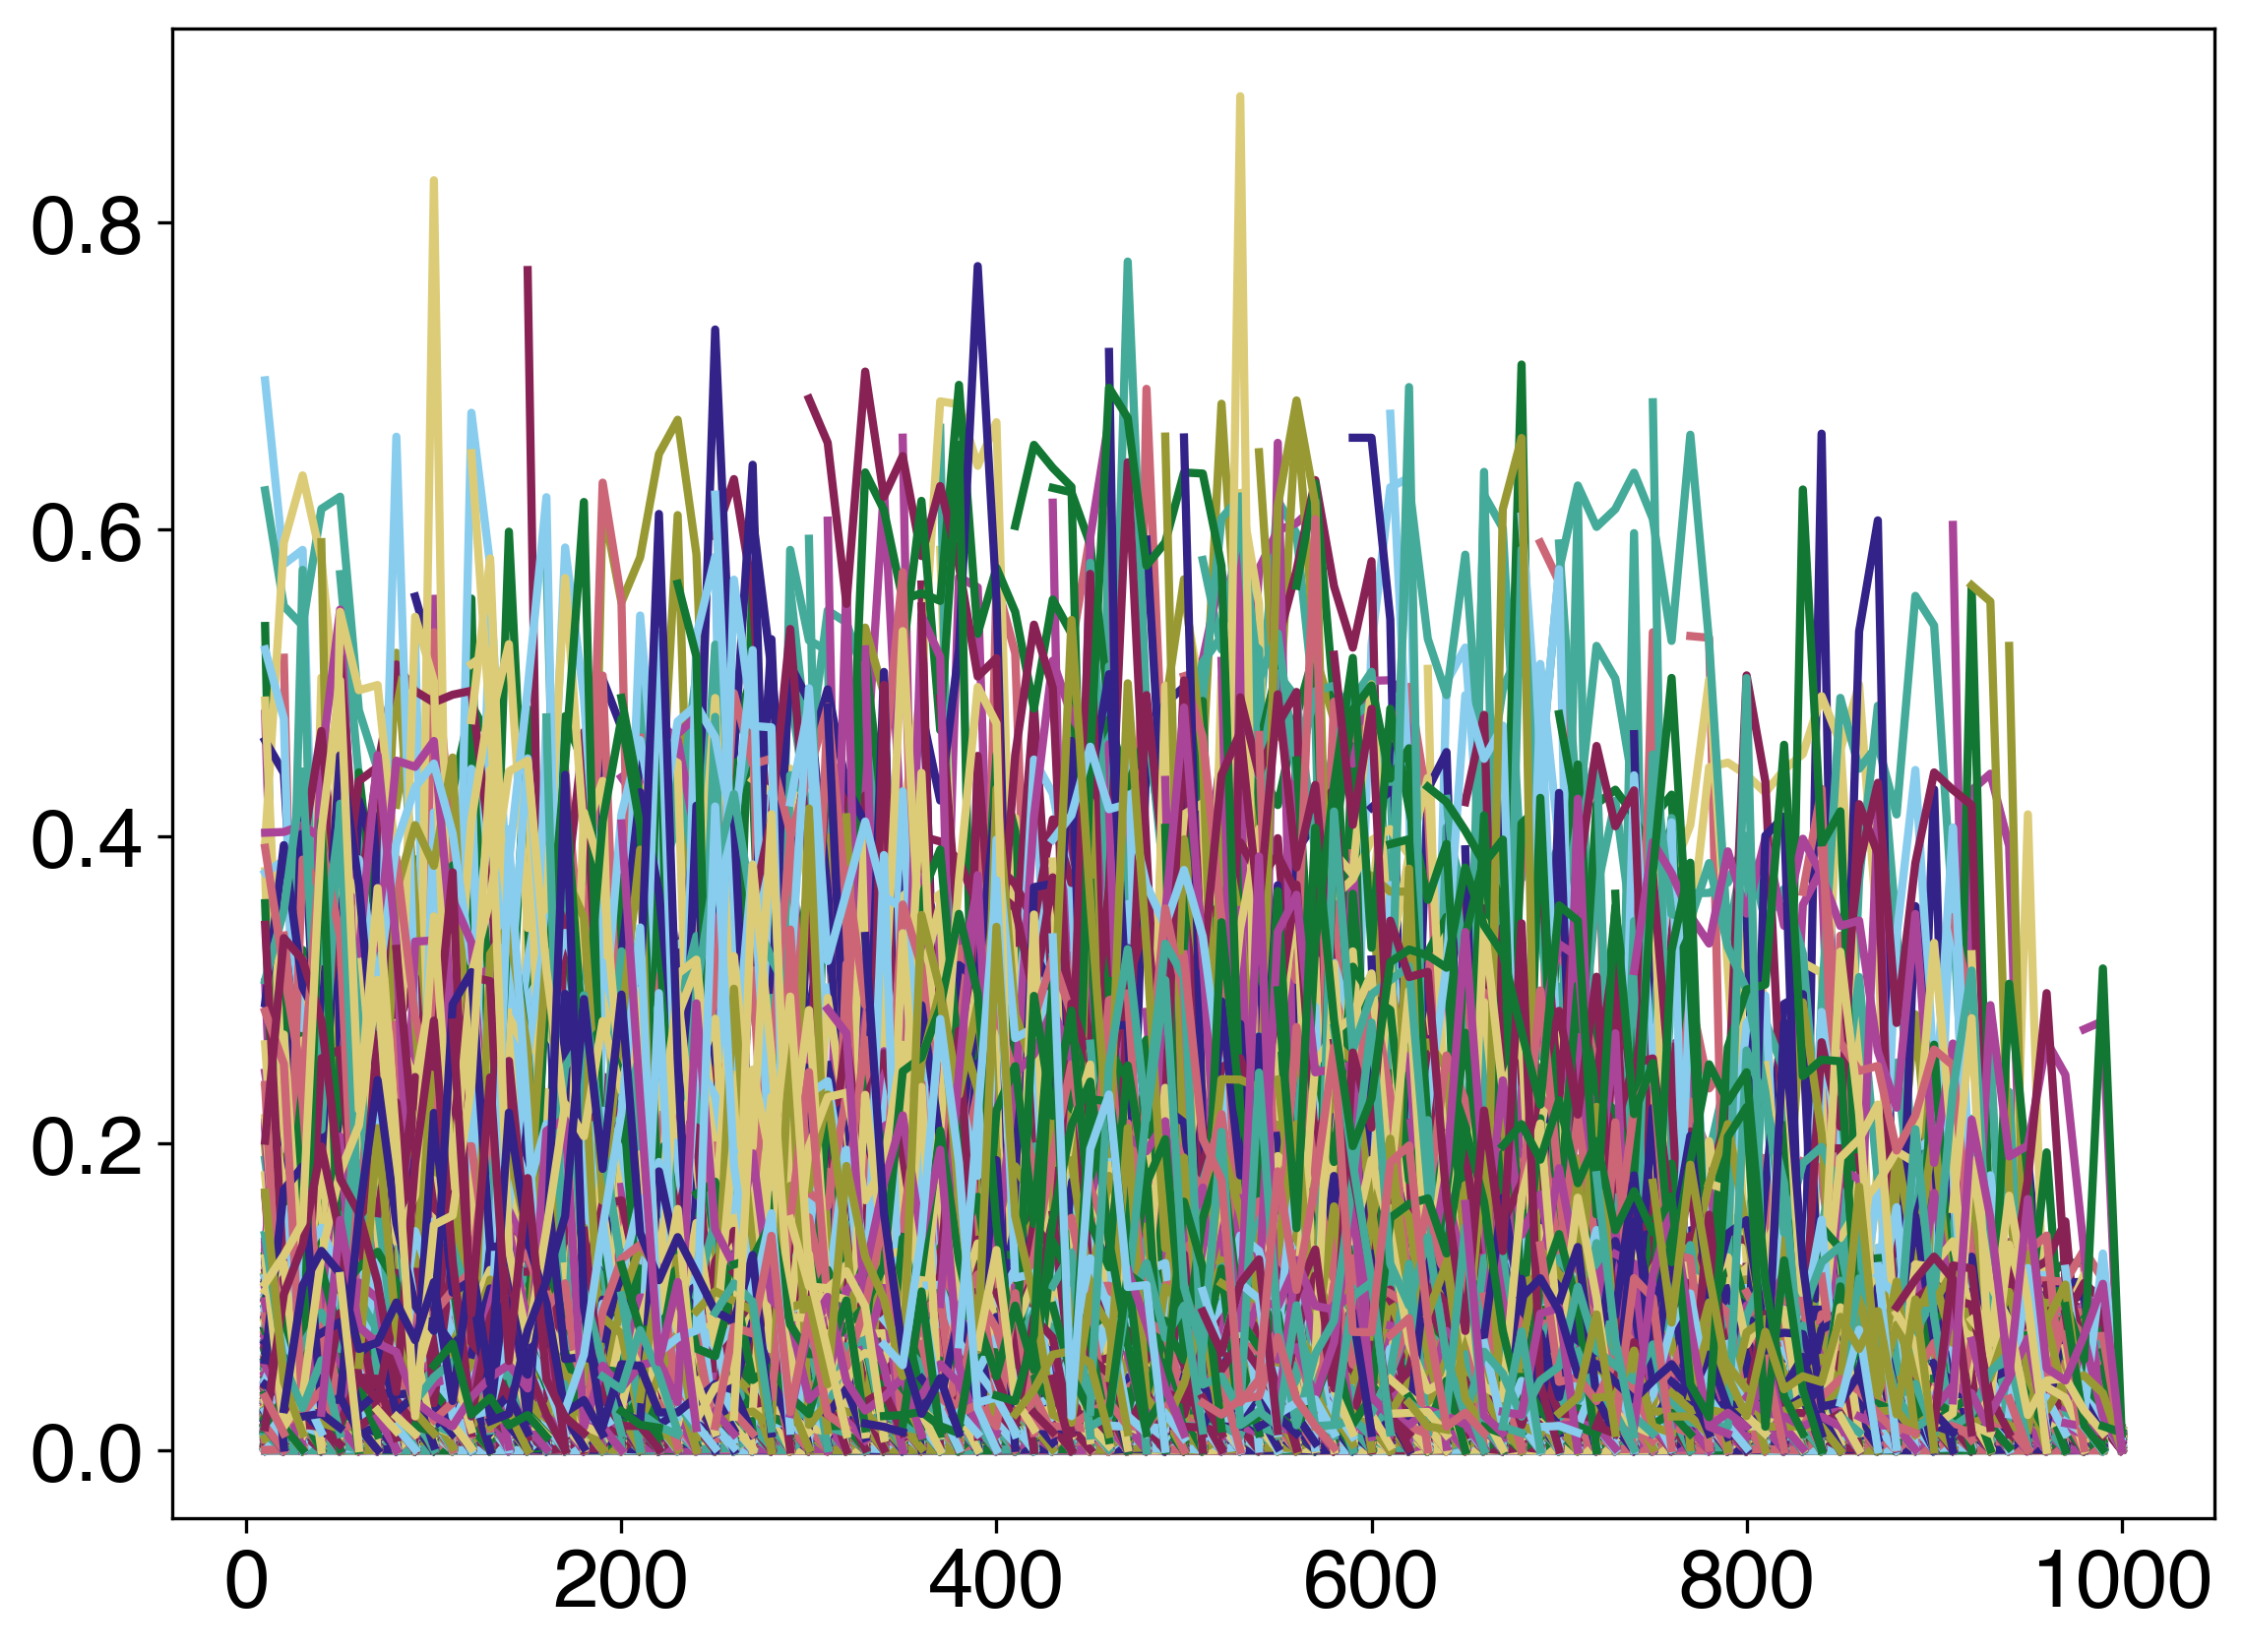

In [ ]:
from cal_vel import low_area, pulses

wts = [[],[]]

for i in range(len(tracks)):
    for t in tracks[i]:
        wt = low_area(t, threshold=0.015, min_low_duration=1,time_interval=interval, xlabel = 'time(sec)', ylabel = 'velocity(um/s)', ylim = (0.0, 0.7), display = False)
        wts[i].append(wt)

tts = [[],[]]

for i in range(len(tracks)):
    for t in tracks[i]:
        tt = pulses(t, threshold=0.015, time_interval=interval, display = False)
        tts[i].append(tt)


[ 10  30  50  70  90 110 130 150 170 190 210 230 250 270 290 310 330 350
 370 390 410 430 450 470 490 510 530 550 570 590 610 630 650 670 690 710
 730 750 770 790 810 830 850 870 890 910 930 950 970 990]


<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_73751/2139909970.py:39: SyntaxWarning: invalid escape sequence '\p'
  ax.text(100, 1e-2, '$\propto \Delta t ^{-2}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_73751/2139909970.py:40: SyntaxWarning: invalid escape sequence '\p'
  ax.text(20, 5*1e-5, '$\propto \Delta t ^{-3}$')


"\nfig.savefig(f'{output}_{d_today}.pdf', bbox_inches='tight')\nfig.savefig(f'{output}_{d_today}.png', bbox_inches='tight')\n"

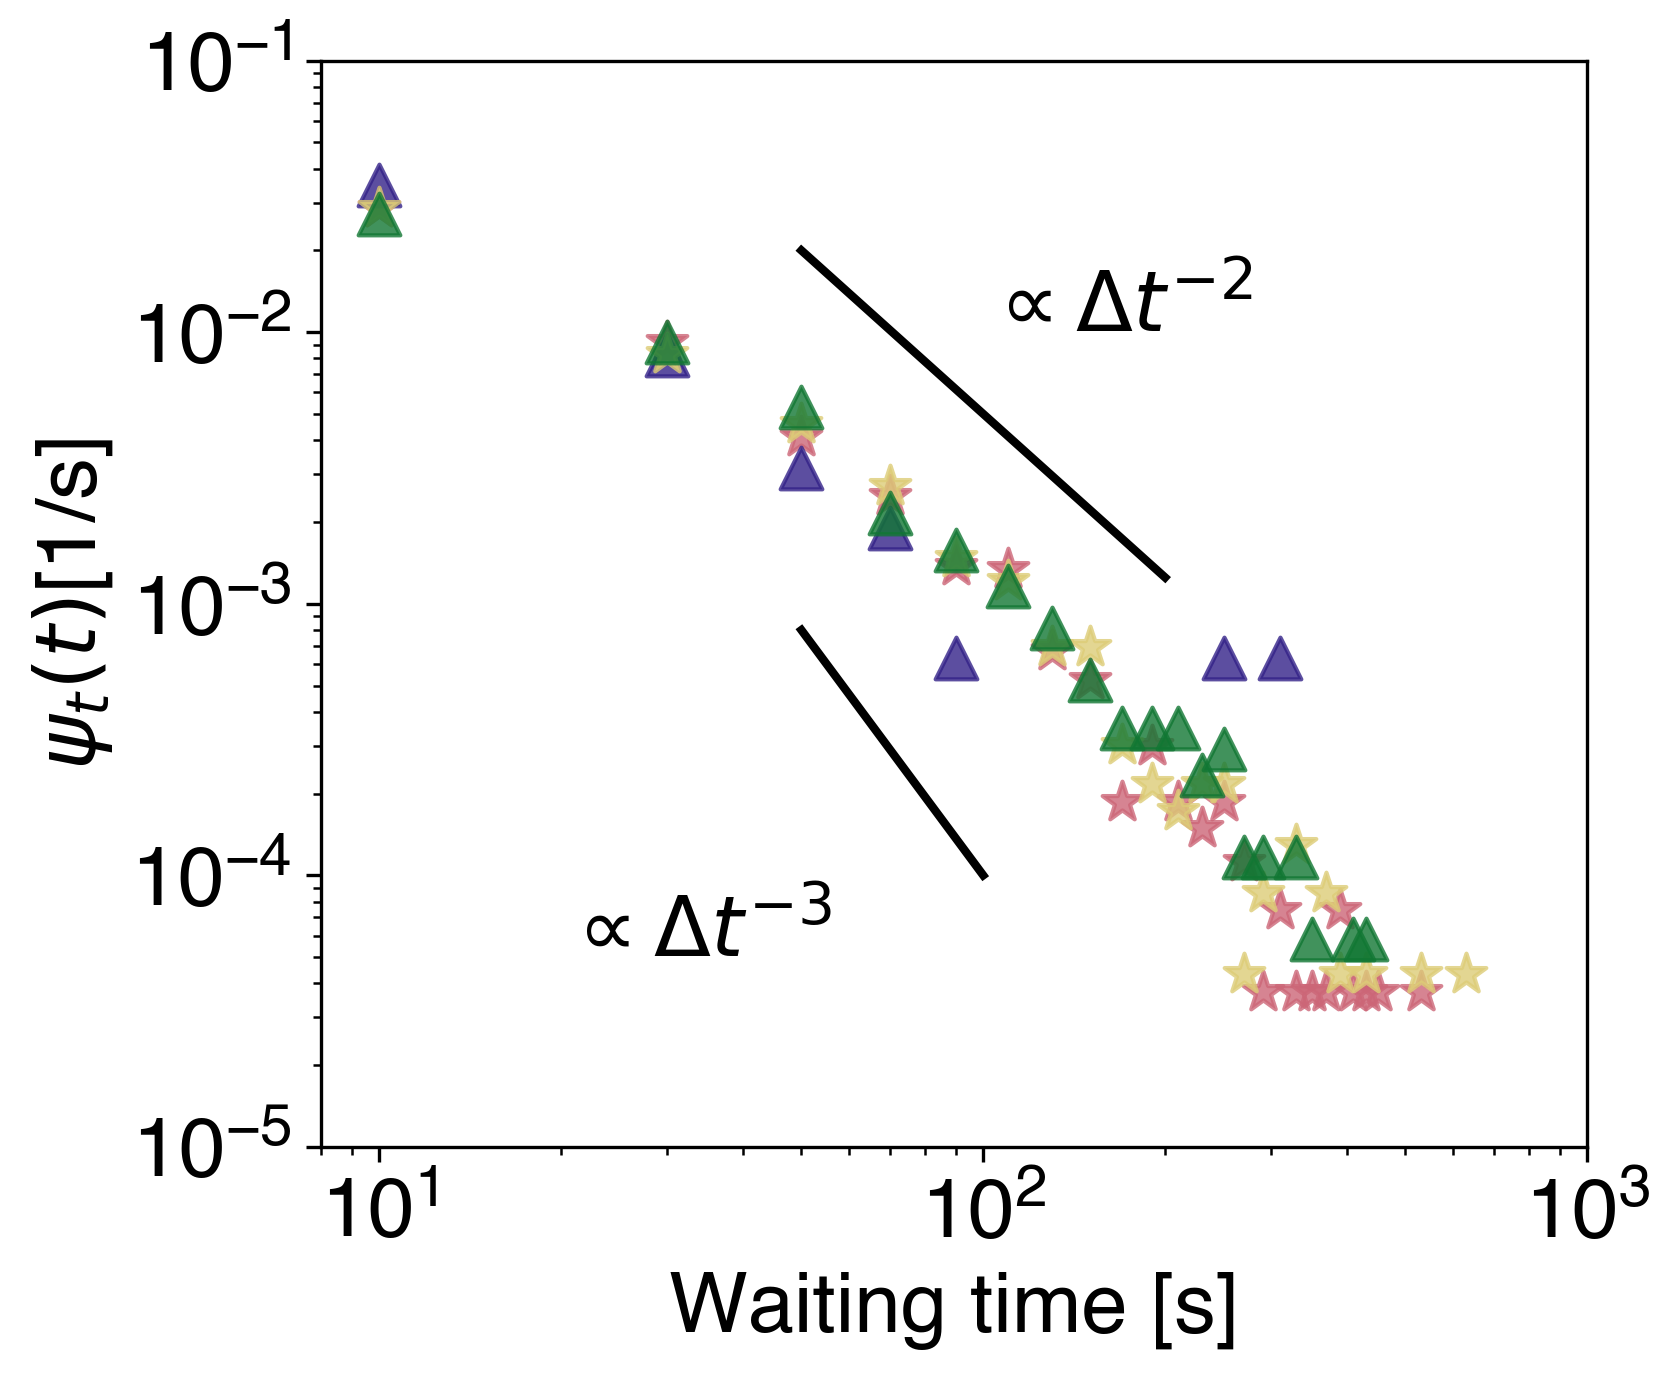

In [ ]:
import datetime
d_today = datetime.date.today()

output = r'/Users/sasakinozomu/Documents/analysis/Output/Wt'

bins = np.arange(10, 1001, 20)
print(bins)
figsize = (6,5)

min_fit, max_fit = 50,110

def get_hist(df, min_fit, max_fit, marker):
    data = df['interval'].values
    # ヒストグラムのデータを計算
    counts, bin_edges = np.histogram(data, bins, density = True)
    indices = np.where((counts>0) & (bin_edges[:-1]>=min_fit) & (bin_edges[:-1]<=max_fit))
    popt, pcov = curve_fit(fm.ln_pl, np.log10(bin_edges[indices]), np.log10(counts[indices]))
    fit = fm.power_law(bins, popt[0], popt[1])
    ax.scatter(bin_edges[:-1], counts, marker=markers[marker])
    #ax.plot(bins, fit, color = colors[color], lw = lw, linestyle=lines[line])
    #print(f"MT{MT_conc[MT]}uM MC{mc_conc[mc]}%, {np.abs(popt[0]+1)}")
    
    return counts, bin_edges, popt, pcov

fig, ax  = plt.subplots(figsize=figsize)

counts04, bin_edges04, popt04, _ = get_hist(wts[0][3], min_fit, max_fit, marker=4)
counts34, bin_edges34, popt34, _ = get_hist(wts[1][3], min_fit, max_fit, marker=3)
counts01, bin_edges01, popt01, _ = get_hist(wts[0][1], min_fit, max_fit, marker=4)
counts31, bin_edges31, popt31, _ = get_hist(wts[1][1], min_fit, max_fit, marker=3)


ty = np.linspace(50, 200, 10)
ax.plot(ty, 5*1e1*ty**-2, color = 'black', lw=2)
ty2 = np.linspace(50, 100, 10)
ax.plot(ty2, 1e2*ty2**-3, color = 'black', lw=2)

ax.text(100, 1e-2, '$\propto \Delta t ^{-2}$')
ax.text(20, 5*1e-5, '$\propto \Delta t ^{-3}$')

ax.set(xlim=(0.8*1e1,1000),
       ylim=(1e-5, 1e-1),
       xscale='log',
       yscale = 'log',
       xlabel = 'Waiting time [s]',
       ylabel = '$\\psi_t(t)$[1/s]')
"""
fig.savefig(f'{output}_{d_today}.pdf', bbox_inches='tight')
fig.savefig(f'{output}_{d_today}.png', bbox_inches='tight')
"""

<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_73751/2925137798.py:21: SyntaxWarning: invalid escape sequence '\p'
  ax.text(100, 1e-2, '$\propto \Delta t ^{-1}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_73751/2925137798.py:22: SyntaxWarning: invalid escape sequence '\p'
  ax.text(20, 5*1e-5, '$\propto \Delta t ^{-2}$')


[(8.0, 1000.0),
 (1e-05, 0.1),
 None,
 None,
 Text(0.5, 0, 'Waiting time [s]'),
 Text(0, 0.5, '$\\psi_r(t)$[1/s]')]

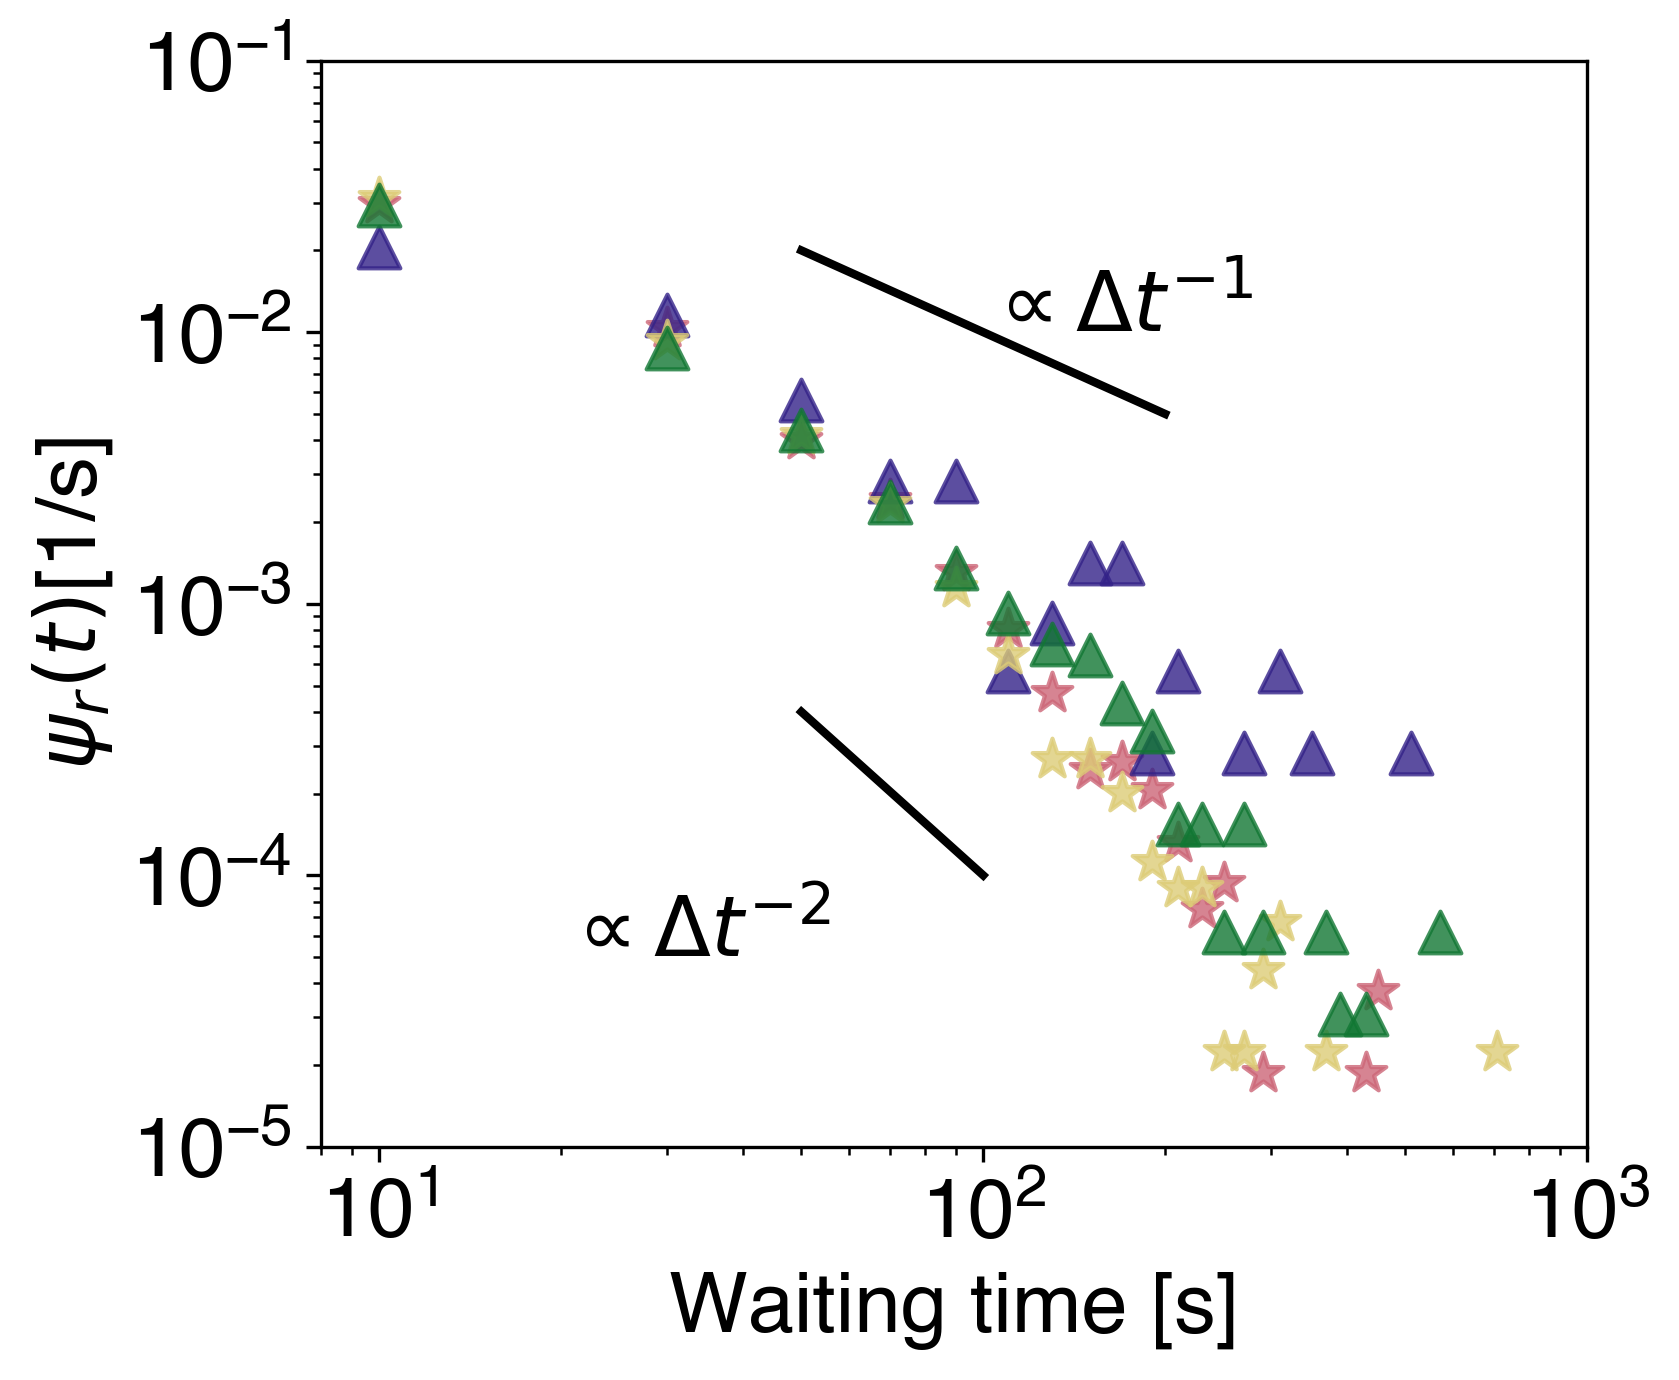

In [ ]:
d_today = datetime.date.today()

output = r'/Users/sasakinozomu/Documents/analysis/Output/Tt'

bins = np.arange(10, 1001, 20)
min_fit, max_fit = 50, 400

fig, ax  = plt.subplots(figsize=figsize)

counts04, bin_edges04, popt04, _ = get_hist(tts[0][3], min_fit, max_fit, marker=4)
counts34, bin_edges34, popt34, _ = get_hist(tts[1][3], min_fit, max_fit, marker=3)
counts01, bin_edges01, popt01, _ = get_hist(tts[0][1], min_fit, max_fit, marker=4)
counts31, bin_edges31, popt31, _ = get_hist(tts[1][1], min_fit, max_fit, marker=3)


ty = np.linspace(50, 200, 10)
ax.plot(ty, 1e0*ty**-1, color = 'black', lw=2)
ty2 = np.linspace(50, 100, 10)
ax.plot(ty2, 1e0*ty2**-2, color = 'black', lw=2)

ax.text(100, 1e-2, '$\propto \Delta t ^{-1}$')
ax.text(20, 5*1e-5, '$\propto \Delta t ^{-2}$')

ax.set(xlim=(0.8 * 1e1,1000),
       ylim=(1e-5, 1e-1),
       xscale='log',
       yscale = 'log',
       xlabel = 'Waiting time [s]',
       ylabel = '$\\psi_r(t)$[1/s]')

"""
fig.savefig(f'{output}_{d_today}.pdf', bbox_inches='tight')
fig.savefig(f'{output}_{d_today}.png', bbox_inches='tight')
"""